In [1]:
# ==========================================
# STEP 1: IMPORTS & DATA LOADING
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style for professional presentation
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Load the Datasets (Adjust the file paths if necessary)
print("Loading datasets...")
train_labels = pd.read_csv('data/Train-1542865627584.csv')
beneficiary = pd.read_csv('data/Train_Beneficiarydata-1542865627584.csv')
inpatient = pd.read_csv('data/Train_Inpatientdata-1542865627584.csv')
outpatient = pd.read_csv('data/Train_Outpatientdata-1542865627584.csv')

# Add a flag to distinguish claim types before combining
inpatient['ClaimType'] = 'Inpatient'
outpatient['ClaimType'] = 'Outpatient'

# 2. Merge Inpatient and Outpatient claims into one master claims table
print("Merging claims data...")
all_claims = pd.concat([inpatient, outpatient], axis=0, ignore_index=True)

# 3. Join with Beneficiary (Patient) Data
print("Joining Beneficiary data...")
master_data = pd.merge(all_claims, beneficiary, on='BeneID', how='left')

# 4. Join with the Target Labels (PotentialFraud) based on Provider ID
print("Joining Fraud Labels...")
master_data = pd.merge(master_data, train_labels, on='Provider', how='left')

print(f"Data merge complete! Final dataset shape: {master_data.shape}")
master_data.head()

Loading datasets...
Merging claims data...
Joining Beneficiary data...
Joining Fraud Labels...
Data merge complete! Final dataset shape: (558211, 56)


,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,PotentialFraud
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,1,1,2,1,1,36000,3204,60,70,Yes
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,...,1,1,2,1,1,36000,3204,60,70,No
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,...,1,1,2,1,1,36000,3204,60,70,No
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,...,1,2,2,1,1,5000,1068,250,320,No
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,...,2,1,2,2,2,21260,2136,120,100,No


In [2]:
# ==========================================
# STEP 3: DATA CLEANING & FEATURE ENGINEERING
# ==========================================
print("Starting Data Cleaning & Feature Engineering...")

# 1. Convert Date columns to actual Pandas datetime objects
date_columns = ['ClaimStartDt', 'ClaimEndDt', 'AdmissionDt', 'DischargeDt', 'DOB', 'DOD']
for col in date_columns:
    master_data[col] = pd.to_datetime(master_data[col], errors='coerce')

# 2. Feature Engineering: Calculate Claim Duration in days
# Fraudsters sometimes submit suspiciously long or extremely short claims
master_data['ClaimDuration'] = (master_data['ClaimEndDt'] - master_data['ClaimStartDt']).dt.days

# 3. Handle Missing Values
# Outpatients won't have certain physicians or admission codes. We fill NaNs with 'None'
fill_none_cols = ['AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'ClmAdmitDiagnosisCode']
master_data[fill_none_cols] = master_data[fill_none_cols].fillna('None')

# 4. Feature Engineering: Count the total number of physicians involved
# Multiple doctors on a simple claim could be a red flag for "upcoding" (a type of fraud)
def count_physicians(row):
    count = 0
    if row['AttendingPhysician'] != 'None': count += 1
    if row['OperatingPhysician'] != 'None': count += 1
    if row['OtherPhysician'] != 'None': count += 1
    return count

master_data['PhysicianCount'] = master_data.apply(count_physicians, axis=1)

print("\nData cleaning and feature engineering applied successfully!")
print("Here are our new engineered features:")
master_data[['ClaimType', 'ClaimDuration', 'PhysicianCount']].head()

Starting Data Cleaning & Feature Engineering...

Data cleaning and feature engineering applied successfully!
Here are our new engineered features:


,ClaimType,ClaimDuration,PhysicianCount
0,Inpatient,6,1
1,Inpatient,2,2
2,Inpatient,3,2
3,Inpatient,8,3
4,Inpatient,17,2


In [4]:
# ==========================================
# STEP 4: FINAL PREPROCESSING FOR ML (FIXED)
# ==========================================
print("Preparing data for the Machine Learning model...")

# 0. Fix the Target Variable First! (Convert 'Yes'/'No' to 1/0)
if master_data['PotentialFraud'].dtype == 'object':
    master_data['PotentialFraud'] = master_data['PotentialFraud'].map({'Yes': 1, 'No': 0})

# 1. Drop IDs, exact dates, and complex diagnostic text codes
cols_to_drop = [
    'BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
    'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician',
    'AdmissionDt', 'DischargeDt', 'DOB', 'DOD', 
    'ClmAdmitDiagnosisCode', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2',
    'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5',
    'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8',
    'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10', 'ClmProcedureCode_1',
    'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4',
    'ClmProcedureCode_5', 'ClmProcedureCode_6'
]

ml_data = master_data.drop(columns=cols_to_drop, errors='ignore')

# 2. Convert remaining text categories into numbers (One-Hot Encoding)
ml_data = pd.get_dummies(ml_data, drop_first=True)

# 3. Handle any leftover missing values by filling them with 0
ml_data = ml_data.fillna(0)

# 4. Separate Features (X) and Target (y)
X = ml_data.drop('PotentialFraud', axis=1)
y = ml_data['PotentialFraud']

print(f"Final Features Shape (X): {X.shape}")
print(f"Target Shape (y): {y.shape}")
print("\nPreprocessing complete! The data is now 100% numeric.")

Preparing data for the Machine Learning model...
Final Features Shape (X): (558211, 762)
Target Shape (y): (558211,)

Preprocessing complete! The data is now 100% numeric.


Splitting data into Train and Test sets...
Training the Random Forest Classifier... (This might take a minute)
Generating predictions...

       MODEL EVALUATION REPORT
                precision    recall  f1-score   support

   Genuine (0)       0.73      0.82      0.77     69083
Fraudulent (1)       0.63      0.51      0.57     42560

      accuracy                           0.70    111643
     macro avg       0.68      0.67      0.67    111643
  weighted avg       0.70      0.70      0.69    111643



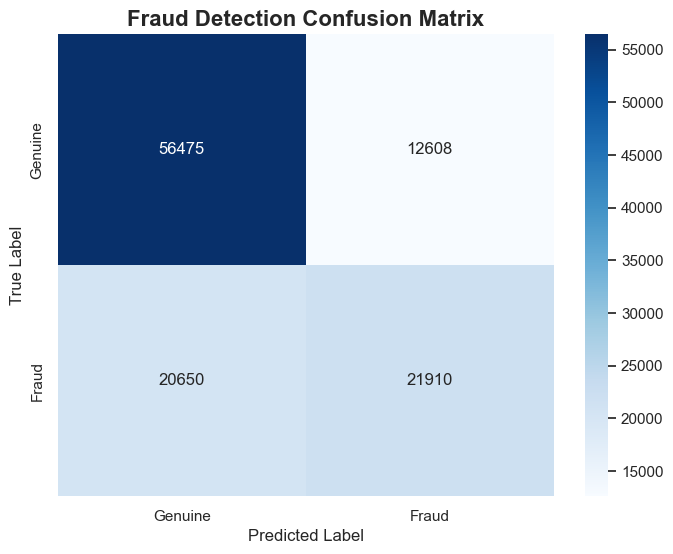

In [5]:
# ==========================================
# STEP 5: MODEL TRAINING & EVALUATION
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Split the data into Training (80%) and Testing (20%) sets
# 'stratify=y' ensures both sets have the same ratio of fraud to non-fraud
print("Splitting data into Train and Test sets...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Initialize and Train the Model
# class_weight='balanced' automatically handles our imbalanced fraud data!
print("Training the Random Forest Classifier... (This might take a minute)")
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 3. Make Predictions on the Test Set
print("Generating predictions...")
y_pred = rf_model.predict(X_test)

# 4. Evaluate the Model (Precision, Recall, F1-Score)
print("\n" + "="*40)
print("       MODEL EVALUATION REPORT")
print("="*40)
print(classification_report(y_test, y_pred, target_names=['Genuine (0)', 'Fraudulent (1)']))

# 5. Visualize the Confusion Matrix for the Final Deliverable
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Genuine', 'Fraud'], 
            yticklabels=['Genuine', 'Fraud'])
plt.title('Fraud Detection Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

Calculating which factors are most suspicious...


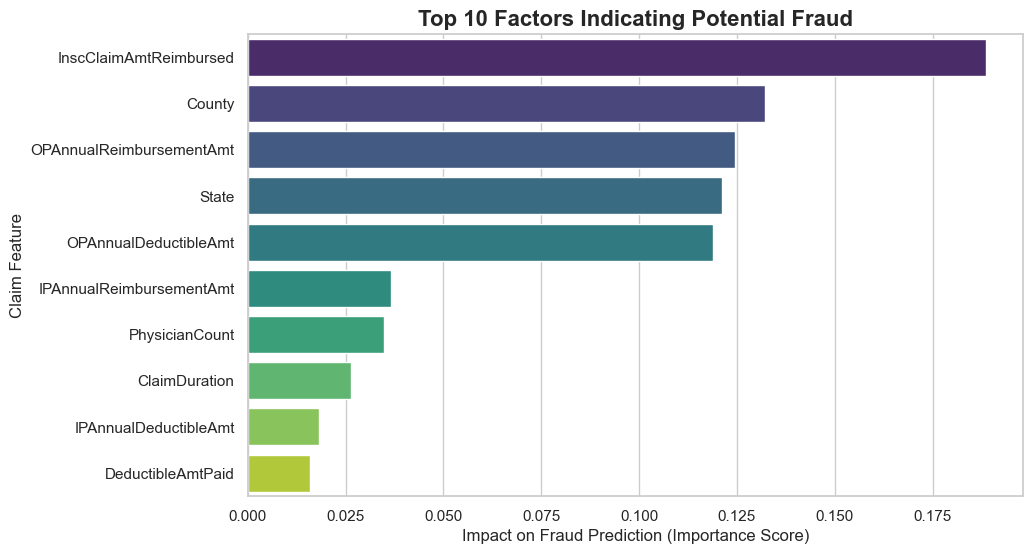

In [7]:
# ==========================================
# STEP 6: WHAT DRIVES FRAUD? (FEATURE IMPORTANCE)
# ==========================================
print("Calculating which factors are most suspicious...")

# Get feature importances from the trained model
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame to sort and plot them
feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the Top 10 Most Important Features
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_df.head(10), 
    hue='Feature',          # <--- Fixes the warning
    palette='viridis', 
    legend=False            # <--- Fixes the warning
)
plt.title('Top 10 Factors Indicating Potential Fraud', fontsize=16, fontweight='bold')
plt.xlabel('Impact on Fraud Prediction (Importance Score)', fontsize=12)
plt.ylabel('Claim Feature', fontsize=12)
plt.show()

In [8]:
# ==========================================
# STEP 7: EXPORT GRAPHS FOR PRESENTATION
# ==========================================
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Exporting high-resolution graphs...")

# 1. Create a folder to store the images
output_folder = "visualizations"
os.makedirs(output_folder, exist_ok=True)

# 2. Save the Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Genuine', 'Fraud'], 
            yticklabels=['Genuine', 'Fraud'])
plt.title('Fraud Detection Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)

# Save as PNG with 300 DPI (High Definition for LinkedIn/GitHub)
cm_path = os.path.join(output_folder, 'confusion_matrix.png')
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
plt.close() # Closes the figure so it doesn't display duplicate outputs in the notebook

# 3. Save the Feature Importance Graph
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_df.head(10), 
    hue='Feature',          
    palette='viridis', 
    legend=False            
)
plt.title('Top 10 Factors Indicating Potential Fraud', fontsize=16, fontweight='bold')
plt.xlabel('Impact on Fraud Prediction (Importance Score)', fontsize=12)
plt.ylabel('Claim Feature', fontsize=12)

# Save as PNG
feature_path = os.path.join(output_folder, 'feature_importance.png')
plt.savefig(feature_path, dpi=300, bbox_inches='tight')
plt.close()

print(f"Success! Your HD graphs have been saved inside the '{output_folder}' folder.")

Exporting high-resolution graphs...
Success! Your HD graphs have been saved inside the 'visualizations' folder.
